# Notebook 12 — Generalization Evaluation

**Purpose:** Unified generalization evaluation across all FSL methods and backbones  
for one dataset. Produces the thesis-ready generalization results table.

**Generalization = test on unseen users, NO adaptation of any kind.**

**What this notebook does that individual method notebooks don't:**
- Re-evaluates ALL methods with **identical episode seeds** for fair comparison
- Collects results from checkpoints saved by notebooks 08–11
- Generates a unified comparison table across methods × backbones
- Produces the K-shot generalization curves for all methods on one plot

**Evaluation protocol:**
- `N_EPISODES_EVAL` episodes per (method, backbone, K) combination
- Fixed seed across all methods → same episode draws → fair comparison
- Metrics: mean accuracy ± 95% CI, macro F1

**Run this notebook:**
- Once per dataset after all method notebooks have been run
- Set `DATASET_NAME` in Cell 1
- Results saved to `RESULTS_BASE/generalization_{dataset}.csv`

---
**Requires:** All backbone checkpoints and FSL checkpoints for the chosen dataset.

## Cell 1 — Setup

In [7]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"

# ── Backbone class definitions — inline, no %run ──────────────────────────────

# StreamCNNEncoder built to match EXACTLY what notebook 05 saved.
# Confirmed from checkpoint inspector:
#   encoder.0  = Conv1d(in→32, k=7)     encoder.1  = BN(32)
#   encoder.2  = ReLU (no params)       encoder.3  = MaxPool (no params)
#   encoder.4  = ReLU or MaxPool        encoder.5  = Conv1d(32→64, k=5)
#   encoder.6  = BN(64)                 encoder.7  = ReLU (no params)
#   encoder.8  = MaxPool (no params)    encoder.9  = ReLU (no params)
#   encoder.10 = Conv1d(64→64, k=3)    encoder.11 = BN(64)
#   encoder.12 = ReLU (no params)      encoder.13 = AdaptiveAvgPool (no params)
#
# Indices 2,3,4,7,8,9,12,13 have no learnable params so absent from checkpoint.
# The unusual gap at 3,4 means there are TWO param-free layers between BN(32)
# and Conv(32→64) — that is MaxPool then ReLU (or ReLU then MaxPool twice).
# We hardcode: 0=Conv,1=BN,2=ReLU,3=MaxPool,4=ReLU,5=Conv,6=BN,7=ReLU,
#              8=MaxPool,9=ReLU,10=Conv,11=BN,12=ReLU,13=AdaptiveAvgPool

class StreamCNNEncoder(nn.Module):
    def __init__(self, in_channels=3, d_stream=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),  # 0
            nn.BatchNorm1d(32),                                      # 1
            nn.ReLU(),                                               # 2
            nn.MaxPool1d(kernel_size=2, stride=2),                  # 3
            nn.ReLU(),                                               # 4  ← extra
            nn.Conv1d(32, 64, kernel_size=5, padding=2),            # 5
            nn.BatchNorm1d(64),                                      # 6
            nn.ReLU(),                                               # 7
            nn.MaxPool1d(kernel_size=2, stride=2),                  # 8
            nn.ReLU(),                                               # 9  ← extra
            nn.Conv1d(64, d_stream, kernel_size=3, padding=1),      # 10
            nn.BatchNorm1d(d_stream),                                # 11
            nn.ReLU(),                                               # 12
            nn.AdaptiveAvgPool1d(1),                                 # 13
        )
    def forward(self, x):
        return self.encoder(x.permute(0, 2, 1)).squeeze(-1)


class CNNBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, in_channels=3,
                 d_stream=64, embedding_dim=EMBEDDING_DIM):
        super().__init__()
        self.n_streams     = n_streams
        self.embedding_dim = embedding_dim
        self.stream_encoders = nn.ModuleList([
            StreamCNNEncoder(in_channels, d_stream) for _ in range(n_streams)
        ])
        self.fusion     = nn.Sequential(
            nn.Linear(n_streams * d_stream, embedding_dim), nn.ReLU())
        self.classifier = nn.Linear(embedding_dim, n_classes)
    def forward(self, stream_list, return_embedding=False):
        fused = torch.cat(
            [enc(s) for enc, s in zip(self.stream_encoders, stream_list)],
            dim=-1)
        emb = self.fusion(fused)
        return emb if return_embedding else self.classifier(emb)
    def get_embedding(self, stream_list):
        return self.forward(stream_list, return_embedding=True)


class StreamLSTMEncoder(nn.Module):
    def __init__(self, input_size=3, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.d_stream = hidden_size * 2
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.dropout(out[:, -1, :])


class LSTMBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, input_size=3,
                 hidden_size=64, num_layers=2, dropout=0.3,
                 embedding_dim=EMBEDDING_DIM):
        super().__init__()
        self.n_streams     = n_streams
        self.embedding_dim = embedding_dim
        d_stream           = hidden_size * 2
        self.stream_encoders = nn.ModuleList([
            StreamLSTMEncoder(input_size, hidden_size, num_layers, dropout)
            for _ in range(n_streams)
        ])
        self.fusion = nn.Sequential(
            nn.Linear(n_streams * d_stream, embedding_dim),
            nn.ReLU(), nn.Dropout(0.2))
        self.classifier = nn.Linear(embedding_dim, n_classes)
    def forward(self, stream_list, return_embedding=False):
        fused = torch.cat(
            [enc(s) for enc, s in zip(self.stream_encoders, stream_list)],
            dim=-1)
        emb = self.fusion(fused)
        return emb if return_embedding else self.classifier(emb)
    def get_embedding(self, stream_list):
        return self.forward(stream_list, return_embedding=True)


class StreamTemporalEncoder(nn.Module):
    def __init__(self, in_channels=3, d_model=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4, 4),
            nn.Conv1d(32, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
    def forward(self, x):
        return self.encoder(x.permute(0, 2, 1)).squeeze(-1)


class TransformerBackbone(nn.Module):
    def __init__(self, n_streams, n_classes, in_channels=3,
                 d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=256, dropout=0.1,
                 embedding_dim=EMBEDDING_DIM):
        super().__init__()
        assert d_model % nhead == 0
        self.n_streams     = n_streams
        self.embedding_dim = embedding_dim
        self.stream_encoders = nn.ModuleList([
            StreamTemporalEncoder(in_channels, d_model)
            for _ in range(n_streams)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.sensor_pos_embedding = nn.Parameter(
            torch.randn(1, n_streams + 1, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer_encoder = nn.TransformerEncoder(
            enc_layer, num_layers=num_layers,
            norm=nn.LayerNorm(d_model))
        self.projection = nn.Sequential(
            nn.Linear(d_model, embedding_dim), nn.ReLU())
        self.classifier = nn.Linear(embedding_dim, n_classes)
        self.dropout    = nn.Dropout(dropout)
        self._init_weights()
    def _init_weights(self):
        nn.init.normal_(self.cls_token,            std=0.02)
        nn.init.normal_(self.sensor_pos_embedding, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, stream_list, return_embedding=False):
        b      = stream_list[0].shape[0]
        tokens = torch.stack(
            [enc(s) for enc, s
             in zip(self.stream_encoders, stream_list)], dim=1)
        cls    = self.cls_token.expand(b, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1) \
                 + self.sensor_pos_embedding
        tokens = self.dropout(tokens)
        enc    = self.transformer_encoder(tokens)
        emb    = self.projection(enc[:, 0, :])
        return emb if return_embedding else self.classifier(emb)
    def get_embedding(self, stream_list):
        return self.forward(stream_list, return_embedding=True)


BACKBONE_CLASSES = {
    'cnn'        : CNNBackbone,
    'lstm'       : LSTMBackbone,
    'transformer': TransformerBackbone,
}

DATASET_NAME = 'wisdm'
EVAL_SEED    = MASTER_SEED + 100

print(f'\n✅ Setup complete')
print(f'   Dataset  : {DATASET_NAME}')
print(f'   Eval seed: {EVAL_SEED}')
print(f'   Episodes : {N_EPISODES_EVAL}')
print(f'   K values : {K_SHOTS}')
print(f'   Device   : {DEVICE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subje

## Cell 2 — Load Dataset

In [8]:
## Cell 2 — Load Dataset

data = load_processed_dataset(DATASET_NAME)

streams      = data['streams']
y            = data['y']
subject_ids  = data['subject_ids']
stream_names = data['stream_names']
split_info   = data['split_info']
cfg          = data['config']
sam          = data.get('subject_activity_map')

n_streams = len(stream_names)
n_classes = cfg['n_classes']
n_way     = cfg['n_way']
N, T, C   = streams[stream_names[0]].shape

# ── String-convert subject IDs everywhere ─────────────────────────────────────
sub_ids_str        = subject_ids.astype(str)
train_subjects_str = [str(s) for s in split_info['train']]
val_subjects_str   = [str(s) for s in split_info['val']]
test_subjects_str  = [str(s) for s in split_info['test']]

test_mask = get_split_mask(sub_ids_str, test_subjects_str)

print(f'── Dataset: {DATASET_NAME} ──')
print(f'   N={N:,} | streams={n_streams} | classes={n_classes} | n_way={n_way}')
print(f'   Test windows : {test_mask.sum():,}')
print(f'   Test subjects: {test_subjects_str}')

✅ Loaded "wisdm" — 63513 windows | 4 streams
── Dataset: wisdm ──
   N=63,513 | streams=4 | classes=18 | n_way=5
   Test windows : 8,880
   Test subjects: ['1649', '1602', '1636', '1633', '1601', '1613', '1608']


## Cell 3 — Build Backbone Kwargs and Episode Sampler

In [9]:
# Build backbone kwargs AFTER Cell 2 so n_streams, n_classes, C are known.
BACKBONE_KWARGS = {
    'cnn': dict(
        n_streams=n_streams, n_classes=n_classes,
        in_channels=C, d_stream=64, embedding_dim=EMBEDDING_DIM),
    'lstm': dict(
        n_streams=n_streams, n_classes=n_classes,
        input_size=C, hidden_size=64, num_layers=2,
        dropout=0.3, embedding_dim=EMBEDDING_DIM),
    'transformer': dict(
        n_streams=n_streams, n_classes=n_classes,
        in_channels=C, d_model=64, nhead=4, num_layers=2,
        dim_feedforward=256, dropout=0.1, embedding_dim=EMBEDDING_DIM),
}

CKPT_FILENAMES = {
    'pretrain': 'best_backbone.pt',
    'protonet': 'protonet/best_protonet.pt',
    'lee'     : 'best_backbone.pt',
    'maml'    : 'maml/best_maml.pt',
    'supcon'  : 'supcon/best_supcon.pt',
}

# ── Fix subject ID type mismatch ──────────────────────────────────────────────
# split_info['test'] may contain strings ('1649') while subject_ids in the
# numpy array may be integers or objects. Coerce both to the same type by
# matching whatever type subject_ids actually contains.
raw_test_subjects = split_info['test']
actual_unique     = np.unique(subject_ids).tolist()

# Determine whether subject_ids are stored as int or str
if actual_unique and isinstance(actual_unique[0], (int, np.integer)):
    # Convert split_info subjects to int to match
    test_subjects_typed = [int(s) for s in raw_test_subjects]
elif actual_unique and isinstance(actual_unique[0], str):
    # Convert to str
    test_subjects_typed = [str(s) for s in raw_test_subjects]
else:
    test_subjects_typed = raw_test_subjects

# Verify overlap
overlap = [s for s in test_subjects_typed if s in actual_unique]
print(f'Subject ID type in array  : {type(actual_unique[0]).__name__}')
print(f'Subject ID type in split  : {type(raw_test_subjects[0]).__name__}')
print(f'Test subjects (typed)     : {test_subjects_typed}')
print(f'Overlap with actual data  : {len(overlap)}/{len(test_subjects_typed)}')

if len(overlap) == 0:
    print('\n⚠ ZERO overlap — subject IDs in split_info do not match subject_ids '
          'in the data array. Check preprocessing notebook saved them consistently.')
else:
    # Build sampler with correctly typed subjects
    test_sampler_gen = EpisodeSampler(
        stream_arrays        = streams,
        y                    = y,
        subject_ids          = subject_ids,
        subject_split        = test_subjects_typed,
        n_way                = n_way,
        n_query              = N_QUERY,
        subject_activity_map = sam,
        seed                 = EVAL_SEED,
    )

    print(f'\n✅ Config ready')
    print(f'   n_streams : {n_streams}  |  n_classes: {n_classes}  |  n_way: {n_way}')
    print(f'   Backbones : {list(BACKBONE_KWARGS.keys())}')
    print(f'   Methods   : {ALL_FSL_METHODS}')
    print(f'   Available test classes: {len(test_sampler_gen.available_classes)}')

Subject ID type in array  : int
Subject ID type in split  : str
Test subjects (typed)     : [1649, 1602, 1636, 1633, 1601, 1613, 1608]
Overlap with actual data  : 7/7

✅ Config ready
   n_streams : 4  |  n_classes: 18  |  n_way: 5
   Backbones : ['cnn', 'lstm', 'transformer']
   Methods   : ['protonet', 'lee', 'maml', 'supcon']
   Available test classes: 18


## Cell 4 — Checkpoint Discovery

Scan checkpoint directory to see which (backbone, method) combinations  
have been trained and are available for evaluation.

In [10]:
# Checkpoint paths per method
CKPT_FILENAMES = {
    'pretrain' : 'best_backbone.pt',
    'protonet' : 'protonet/best_protonet.pt',
    'lee'      : 'best_backbone.pt',       # LEE starts from pre-trained backbone
    'maml'     : 'maml/best_maml.pt',
    'supcon'   : 'supcon/best_supcon.pt',
}

available_configs = []
missing_configs   = []

print(f'Scanning checkpoints for dataset: {DATASET_NAME}\n')
print(f'{"Backbone":<15} {"Method":<12} {"Checkpoint":<10} {"Status"}')
print('─' * 60)

for backbone_type in ALL_BACKBONES:
    for method in ['pretrain'] + ALL_FSL_METHODS:
        ckpt_filename = CKPT_FILENAMES.get(method)
        if ckpt_filename is None:
            continue

        ckpt_path = os.path.join(
            CHECKPOINT_BASE, DATASET_NAME, backbone_type, ckpt_filename
        )
        exists = os.path.exists(ckpt_path)
        status = '✅ found' if exists else '❌ missing'

        print(f'{backbone_type:<15} {method:<12} ...{ckpt_filename[-20:]:<25} {status}')

        if exists:
            available_configs.append({
                'backbone' : backbone_type,
                'method'   : method,
                'ckpt_path': ckpt_path,
            })
        else:
            missing_configs.append((backbone_type, method))

print(f'\n   Available: {len(available_configs)} | Missing: {len(missing_configs)}')
if missing_configs:
    print(f'   Missing configs (will be skipped):')
    for b, m in missing_configs:
        print(f'     {b} × {m}')


Scanning checkpoints for dataset: wisdm

Backbone        Method       Checkpoint Status
────────────────────────────────────────────────────────────
cnn             pretrain     ...best_backbone.pt          ✅ found
cnn             protonet     ...net/best_protonet.pt      ✅ found
cnn             lee          ...lee/best_backbone.pt      ❌ missing
cnn             maml         ...maml/best_maml.pt         ✅ found
cnn             supcon       ...upcon/best_supcon.pt      ✅ found
lstm            pretrain     ...best_backbone.pt          ✅ found
lstm            protonet     ...net/best_protonet.pt      ✅ found
lstm            lee          ...lee/best_backbone.pt      ❌ missing
lstm            maml         ...maml/best_maml.pt         ✅ found
lstm            supcon       ...upcon/best_supcon.pt      ✅ found
transformer     pretrain     ...best_backbone.pt          ✅ found
transformer     protonet     ...net/best_protonet.pt      ✅ found
transformer     lee          ...lee/best_backbone.pt   

## Cell 5 — Generalization Evaluation Core Function

In [11]:
@torch.no_grad()
def evaluate_generalization_episodic(
    backbone    : nn.Module,
    sampler     : EpisodeSampler,
    k_shot      : int,
    n_episodes  : int = N_EPISODES_EVAL,
    seed        : int = EVAL_SEED,
) -> Dict:
    """
    Standardized episodic generalization evaluation.

    Evaluates a backbone using nearest-prototype classification.
    All methods use this same function for fair comparison.

    The fixed seed ensures identical episode draws across all methods,
    making the comparison fully controlled.

    Args:
        backbone   : any backbone with get_embedding(stream_list) interface
        sampler    : EpisodeSampler with fixed seed
        k_shot     : support samples per class
        n_episodes : number of evaluation episodes
        seed       : re-seed sampler before evaluation for reproducibility

    Returns:
        dict with acc_mean, acc_std, ci95, all_accs
    """
    backbone.eval()

    # Re-seed the sampler RNG for reproducibility
    sampler.rng = np.random.default_rng(seed)

    episode_accs  = []
    episode_preds = []
    episode_labs  = []

    for _ in range(n_episodes):
        episode  = sampler.sample_episode(k_shot=k_shot)

        sup_list = [episode['support_streams'][s].to(DEVICE) for s in stream_names]
        qry_list = [episode['query_streams'][s].to(DEVICE)   for s in stream_names]
        sup_lab  = episode['support_labels'].to(DEVICE)
        qry_lab  = episode['query_labels'].to(DEVICE)

        # Encode
        sup_emb  = backbone.get_embedding(sup_list)   # (n_way*k, D)
        qry_emb  = backbone.get_embedding(qry_list)   # (n_way*n_q, D)

        # Prototypes
        prototypes = torch.zeros(sampler.n_way, EMBEDDING_DIM, device=DEVICE)
        for c in range(sampler.n_way):
            mask = (sup_lab == c)
            if mask.any():
                prototypes[c] = sup_emb[mask].mean(dim=0)

        # Nearest prototype
        diff  = qry_emb.unsqueeze(1) - prototypes.unsqueeze(0)
        dists = (diff ** 2).sum(dim=-1)
        preds = dists.argmin(dim=-1)
        acc   = (preds == qry_lab).float().mean().item()

        episode_accs.append(acc)
        episode_preds.extend(preds.cpu().numpy().tolist())
        episode_labs.extend(qry_lab.cpu().numpy().tolist())

    accs = np.array(episode_accs)
    ci95 = 1.96 * accs.std() / np.sqrt(len(accs))

    # Macro F1 over all episode query predictions
    macro_f1 = compute_macro_f1(
        np.array(episode_labs), np.array(episode_preds)
    )

    return {
        'acc_mean'  : float(accs.mean()),
        'acc_std'   : float(accs.std()),
        'ci95'      : float(ci95),
        'macro_f1'  : float(macro_f1),
        'all_accs'  : episode_accs,
        'n_episodes': n_episodes,
    }


def load_backbone_from_ckpt(
    backbone_type : str,
    ckpt_path     : str,
) -> Optional[nn.Module]:
    """
    Load backbone from checkpoint using strict=False.
    BACKBONE_CLASSES uses inline definitions that match the saved architecture.
    """
    try:
        raw   = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        state = raw.get('model_state_dict', raw.get('state_dict', raw))
    except Exception as e:
        print(f'   ⚠ Cannot open checkpoint: {e}')
        return None

    model = BACKBONE_CLASSES[backbone_type](
        **BACKBONE_KWARGS[backbone_type]).to(DEVICE)

    missing, unexpected = model.load_state_dict(state, strict=False)

    # num_batches_tracked mismatches are always safe to ignore
    critical_missing = [k for k in missing
                        if 'num_batches_tracked' not in k]
    total_params     = len([k for k in state
                            if 'num_batches_tracked' not in k])
    n_loaded         = total_params - len(critical_missing)
    pct              = n_loaded / max(total_params, 1) * 100

    if critical_missing:
        print(f'   ℹ {backbone_type}: {pct:.0f}% weights loaded '
              f'({len(critical_missing)} missing keys)')
        if pct < 70:
            print(f'   ⚠ Only {pct:.0f}% loaded — skipping')
            return None

    model.eval()
    return model


print('✅ load_backbone_from_ckpt ready')


print('✅ load_backbone_from_ckpt ready (auto-detects architecture from checkpoint)')

print('✅ load_backbone_from_ckpt defined with architecture auto-detection')


print('✅ Evaluation functions ready')

✅ load_backbone_from_ckpt ready
✅ load_backbone_from_ckpt ready (auto-detects architecture from checkpoint)
✅ load_backbone_from_ckpt defined with architecture auto-detection
✅ Evaluation functions ready


## Cell 6 — Run All Generalization Evaluations

Evaluates every available (backbone, method) combination at K=1, 5, 10.  
All evaluations use the same fixed episode seed for fair comparison.

In [12]:
# ── Run all generalization evaluations ────────────────────────────────────────
print(f'Running generalization evaluations on {DATASET_NAME}...')
print(f'Fixed seed: {EVAL_SEED} | Episodes: {N_EPISODES_EVAL} | K: {K_SHOTS}\n')

results_csv  = os.path.join(RESULTS_BASE, f'generalization_{DATASET_NAME}.csv')

# Clean old CSV to prevent duplicate accumulation
if os.path.exists(results_csv):
    try:
        os.remove(results_csv)
        print(f"🗑 Deleted old CSV to prevent duplicates: {results_csv}")
    except Exception as e:
        print(f"⚠️ Could not delete old CSV (might be open in another app): {e}")

results      = defaultdict(lambda: defaultdict(dict))
run_count    = 0
total_runs   = len(available_configs) * len(K_SHOTS)

for config in available_configs:
    backbone_type = config['backbone']
    method        = config['method']
    ckpt_path     = config['ckpt_path']

    try:
        backbone = load_backbone_from_ckpt(backbone_type, ckpt_path)
    except Exception as e:
        print(f'   ⚠ Failed to load {backbone_type}/{method}: {e}')
        continue

    # ── GUARD: skip if backbone failed to load ────────────────────────────────
    if backbone is None:
        print(f'   ⏭ Skipping {backbone_type}/{method} — could not load checkpoint')
        continue

    for k in K_SHOTS:
        run_count += 1
        try:
            metrics = evaluate_generalization_episodic(
                backbone, test_sampler_gen, k_shot=k
            )
        except Exception as e:
            print(f'   ⚠ Eval failed {backbone_type}/{method} K={k}: {e}')
            continue

        results[backbone_type][method][k] = metrics

        print(
            f'  [{run_count:>3}/{total_runs}] '
            f'{backbone_type:<12} {method:<12} K={k} '
            f'acc={metrics["acc_mean"]*100:.2f}% '
            f'±{metrics["ci95"]*100:.2f}% '
            f'f1={metrics["macro_f1"]:.3f}'
        )

        result_row = {
            'dataset'    : DATASET_NAME,
            'backbone'   : backbone_type,
            'method'     : method,
            'eval_type'  : 'generalization',
            'k_shot'     : k,
            'seed'       : EVAL_SEED,
            'acc_mean'   : metrics['acc_mean'],
            'acc_std'    : metrics['acc_std'],
            'ci95'       : metrics['ci95'],
            'macro_f1'   : metrics['macro_f1'],
            'n_episodes' : metrics['n_episodes'],
        }
        append_gen_results(result_row, results_csv)

    del backbone
    torch.cuda.empty_cache() if DEVICE.type == 'cuda' else None

print(f'\n✅ Evaluations complete')
print(f'   Results saved to: {results_csv}')


Running generalization evaluations on wisdm...
Fixed seed: 142 | Episodes: 200 | K: [1, 5, 10]

  [  1/36] cnn          pretrain     K=1 acc=76.51% ±1.68% f1=0.765
  [  2/36] cnn          pretrain     K=5 acc=87.33% ±1.17% f1=0.873
  [  3/36] cnn          pretrain     K=10 acc=89.00% ±1.05% f1=0.890
  [  4/36] cnn          protonet     K=1 acc=76.15% ±1.71% f1=0.762
  [  5/36] cnn          protonet     K=5 acc=86.98% ±1.17% f1=0.870
  [  6/36] cnn          protonet     K=10 acc=88.51% ±1.07% f1=0.885
  [  7/36] cnn          maml         K=1 acc=60.55% ±1.62% f1=0.606
  [  8/36] cnn          maml         K=5 acc=78.81% ±1.41% f1=0.788
  [  9/36] cnn          maml         K=10 acc=83.28% ±1.25% f1=0.833
  [ 10/36] cnn          supcon       K=1 acc=74.95% ±1.71% f1=0.750
  [ 11/36] cnn          supcon       K=5 acc=85.49% ±1.16% f1=0.855
  [ 12/36] cnn          supcon       K=10 acc=86.88% ±1.11% f1=0.869
  [ 13/36] lstm         pretrain     K=1 acc=73.43% ±1.63% f1=0.734
  [ 14/36] lstm 

## Cell 7 — Main Results Table

The thesis-ready generalization results table.  
Format: rows = method, columns = backbone × K-shot.

In [13]:
# ─── Build results DataFrame ──────────────────────────────────────────────────
rows = []
for backbone_type in ALL_BACKBONES:
    for method in ['pretrain'] + ALL_FSL_METHODS:
        if method not in results[backbone_type]:
            continue
        for k in K_SHOTS:
            if k not in results[backbone_type][method]:
                continue
            m = results[backbone_type][method][k]
            rows.append({
                'Backbone'  : backbone_type.upper(),
                'Method'    : method,
                'K'         : k,
                'Acc'       : m['acc_mean'],
                'CI95'      : m['ci95'],
                'MacroF1'   : m['macro_f1'],
            })

df_results = pd.DataFrame(rows)

# ─── Pivot: rows=Method, columns=(Backbone, K) ────────────────────────────────
print(f'\n══ Generalization Results — {DATASET_NAME.upper()} ══')
print(f'   Metric: Accuracy (mean ± CI95) | {N_EPISODES_EVAL} episodes | seed={EVAL_SEED}')
print(f'   n_way={n_way} | K_shots={K_SHOTS}')
print()

# Print formatted table
print(f'{"Method":<15}', end='')
for backbone_type in ALL_BACKBONES:
    for k in K_SHOTS:
        print(f'{backbone_type.upper()+" K="+str(k):>16}', end='')
print()
print('─' * (15 + 16 * len(ALL_BACKBONES) * len(K_SHOTS)))

for method in ['pretrain'] + ALL_FSL_METHODS:
    print(f'{method:<15}', end='')
    for backbone_type in ALL_BACKBONES:
        for k in K_SHOTS:
            if (backbone_type in results and
                method in results[backbone_type] and
                k in results[backbone_type][method]):
                m   = results[backbone_type][method][k]
                val = f'{m["acc_mean"]*100:.1f}±{m["ci95"]*100:.1f}'
            else:
                val = '—'
            print(f'{val:>16}', end='')
    print()

print()
print('Format: mean% ± CI95%')


══ Generalization Results — WISDM ══
   Metric: Accuracy (mean ± CI95) | 200 episodes | seed=142
   n_way=5 | K_shots=[1, 5, 10]

Method                  CNN K=1         CNN K=5        CNN K=10        LSTM K=1        LSTM K=5       LSTM K=10 TRANSFORMER K=1 TRANSFORMER K=5TRANSFORMER K=10
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
pretrain               76.5±1.7        87.3±1.2        89.0±1.1        73.4±1.6        85.4±1.2        87.4±1.0        75.2±1.6        84.0±1.3        84.7±1.3
protonet               76.1±1.7        87.0±1.2        88.5±1.1        70.1±1.7        84.5±1.2        87.1±1.1        75.8±1.6        85.3±1.2        86.6±1.2
lee                           —               —               —               —               —               —               —               —               —
maml                   60.6±1.6        78.8±1.4        83.3±1.3      

## Cell 8 — Best Method Per Backbone

In [14]:
print(f'── Best FSL Method Per Backbone (K={max(K_SHOTS)}-shot) ──\n')
k_focus = max(K_SHOTS)

for backbone_type in ALL_BACKBONES:
    if backbone_type not in results:
        continue
    print(f'  {backbone_type.upper()}:')

    method_accs = []
    for method in ALL_FSL_METHODS:
        if (method in results[backbone_type] and
            k_focus in results[backbone_type][method]):
            acc = results[backbone_type][method][k_focus]['acc_mean']
            method_accs.append((method, acc))

    if not method_accs:
        print('    No results yet')
        continue

    method_accs.sort(key=lambda x: -x[1])
    for rank, (method, acc) in enumerate(method_accs, 1):
        ci95 = results[backbone_type][method][k_focus]['ci95']
        star = ' ← BEST' if rank == 1 else ''
        print(f'    {rank}. {method:<12} {acc*100:.2f}% ±{ci95*100:.2f}%{star}')
    print()

── Best FSL Method Per Backbone (K=10-shot) ──

  CNN:
    1. protonet     88.51% ±1.07% ← BEST
    2. supcon       86.88% ±1.11%
    3. maml         83.28% ±1.25%

  LSTM:
    1. protonet     87.08% ±1.08% ← BEST
    2. supcon       86.37% ±1.20%
    3. maml         81.31% ±1.22%

  TRANSFORMER:
    1. protonet     86.61% ±1.18% ← BEST
    2. supcon       84.97% ±1.33%
    3. maml         81.22% ±1.34%



## Cell 9 — K-Shot Generalization Curves (All Methods × All Backbones)

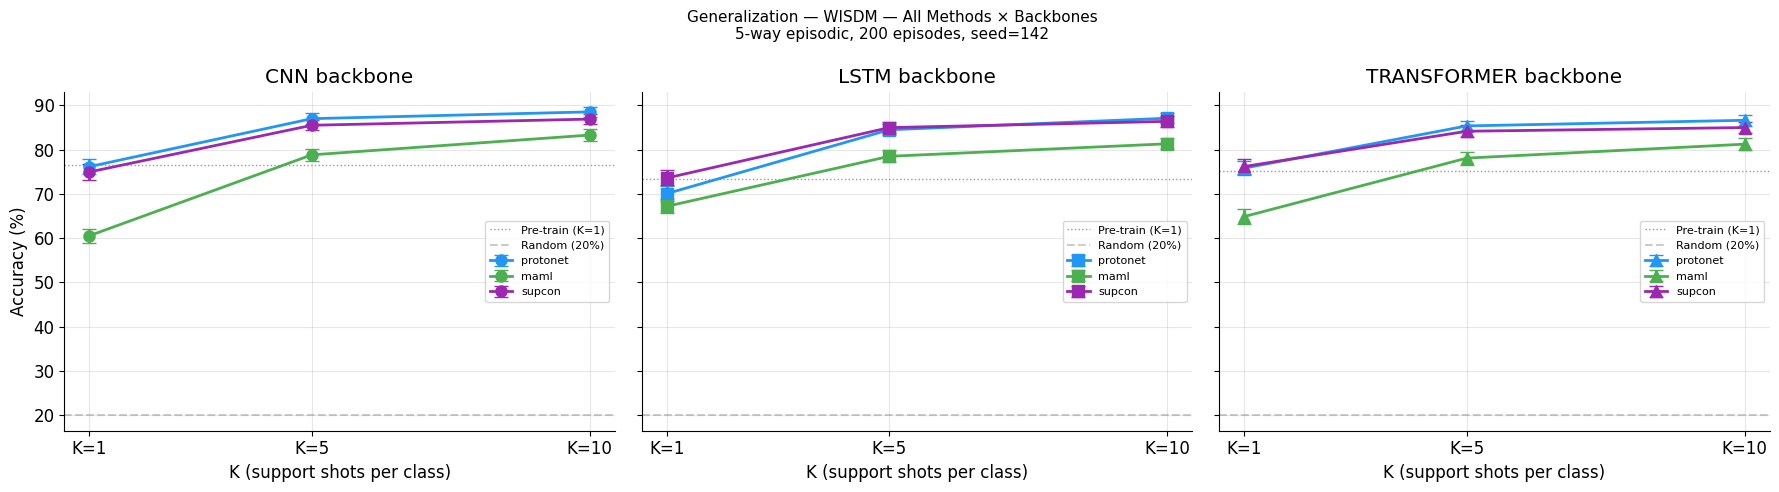

Saved: /content/drive/MyDrive/fsl_har_results/generalization_wisdm_kshot_curves.png


In [15]:
backbones_available = [b for b in ALL_BACKBONES if b in results]
if not backbones_available:
    print('No results to plot yet')
else:
    n_cols = len(backbones_available)
    fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5), sharey=True)
    if n_cols == 1:
        axes = [axes]

    for ax, backbone_type in zip(axes, backbones_available):
        for method in ALL_FSL_METHODS:
            if method not in results[backbone_type]:
                continue

            ks   = sorted(results[backbone_type][method].keys())
            accs = [results[backbone_type][method][k]['acc_mean'] * 100 for k in ks]
            ci95 = [results[backbone_type][method][k]['ci95']     * 100 for k in ks]

            ax.errorbar(
                ks, accs, yerr=ci95,
                label=method,
                color=METHOD_COLORS.get(method, 'gray'),
                marker=BACKBONE_MARKERS.get(backbone_type, 'o'),
                linewidth=2, markersize=8, capsize=5,
            )

        # Pre-train (no FSL) baseline
        if 'pretrain' in results[backbone_type]:
            for k in K_SHOTS:
                if k in results[backbone_type]['pretrain']:
                    pt_acc = results[backbone_type]['pretrain'][k]['acc_mean'] * 100
                    ax.axhline(
                        y=pt_acc, linestyle=':', color='black',
                        alpha=0.4, linewidth=1,
                        label=f'Pre-train (K={k})' if k == K_SHOTS[0] else ''
                    )
                    break

        ax.axhline(y=100/n_way, linestyle='--', color='gray', alpha=0.4,
                   label=f'Random ({100/n_way:.0f}%)')
        ax.set_xticks(K_SHOTS)
        ax.set_xticklabels([f'K={k}' for k in K_SHOTS])
        ax.set_xlabel('K (support shots per class)')
        ax.set_ylabel('Accuracy (%)' if backbone_type == backbones_available[0] else '')
        ax.set_title(f'{backbone_type.upper()} backbone')
        ax.legend(fontsize=8)

    fig.suptitle(
        f'Generalization — {DATASET_NAME.upper()} — All Methods × Backbones\n'
        f'{n_way}-way episodic, {N_EPISODES_EVAL} episodes, seed={EVAL_SEED}',
        fontsize=11
    )
    plt.tight_layout()
    plot_path = os.path.join(RESULTS_BASE, f'generalization_{DATASET_NAME}_kshot_curves.png')
    plt.savefig(plot_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {plot_path}')

## Cell 10 — Heatmap: Accuracy by Method × Backbone (K=10)

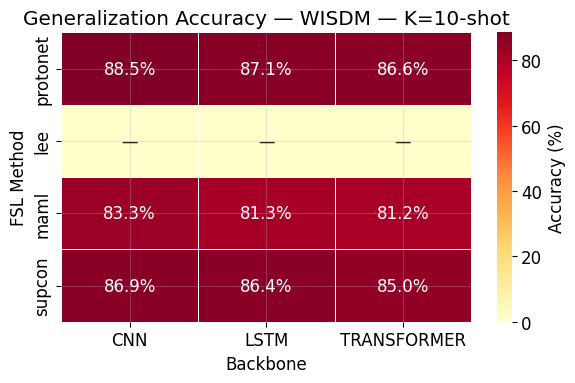

Saved: /content/drive/MyDrive/fsl_har_results/generalization_wisdm_heatmap.png


In [16]:
k_focus = max(K_SHOTS)
methods_available   = ALL_FSL_METHODS
backbones_available = [b for b in ALL_BACKBONES if b in results]

# Build matrix
matrix = np.full((len(methods_available), len(backbones_available)), np.nan)
for i, method in enumerate(methods_available):
    for j, backbone_type in enumerate(backbones_available):
        if (backbone_type in results and
            method in results[backbone_type] and
            k_focus in results[backbone_type][method]):
            matrix[i, j] = results[backbone_type][method][k_focus]['acc_mean'] * 100

if not np.all(np.isnan(matrix)):
    fig, ax = plt.subplots(figsize=(max(5, len(backbones_available)*2), 4))

    # Replace NaN with 0 for display, annotate NaN as '—'
    display_matrix = np.nan_to_num(matrix, nan=0.0)
    annot_matrix   = np.where(
        np.isnan(matrix),
        '—',
        np.vectorize(lambda x: f'{x:.1f}%')(matrix)
    )

    sns.heatmap(
        display_matrix,
        xticklabels = [b.upper() for b in backbones_available],
        yticklabels = methods_available,
        annot       = annot_matrix,
        fmt         = '',
        cmap        = 'YlOrRd',
        linewidths  = 0.5,
        ax          = ax,
        cbar_kws    = {'label': 'Accuracy (%)'},
    )
    ax.set_title(
        f'Generalization Accuracy — {DATASET_NAME.upper()} — K={k_focus}-shot'
    )
    ax.set_xlabel('Backbone')
    ax.set_ylabel('FSL Method')
    plt.tight_layout()
    hm_path = os.path.join(RESULTS_BASE, f'generalization_{DATASET_NAME}_heatmap.png')
    plt.savefig(hm_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {hm_path}')
else:
    print('Not enough results for heatmap yet')

## Cell 11 — Backbone Effect Analysis

For each FSL method: does backbone choice matter?  
Compares performance across CNN / LSTM / Transformer.

In [17]:
k_focus = max(K_SHOTS)
print(f'── Backbone Effect on Generalization (K={k_focus}-shot) ──\n')
print('Question: does backbone choice matter more than FSL method choice?')
print()

# For each method: range of accuracy across backbones
print(f'{"Method":<15} {"Min Acc":>10} {"Max Acc":>10} {"Range":>10} {"Best Backbone"}')
print('─' * 60)

for method in ALL_FSL_METHODS:
    method_backbone_accs = []
    for backbone_type in ALL_BACKBONES:
        if (backbone_type in results and
            method in results[backbone_type] and
            k_focus in results[backbone_type][method]):
            acc = results[backbone_type][method][k_focus]['acc_mean']
            method_backbone_accs.append((backbone_type, acc))

    if len(method_backbone_accs) < 2:
        print(f'{method:<15}  (insufficient data)')
        continue

    accs_only   = [a for _, a in method_backbone_accs]
    best_b, best_a = max(method_backbone_accs, key=lambda x: x[1])
    print(
        f'{method:<15} '
        f'{min(accs_only)*100:>8.2f}% '
        f'{max(accs_only)*100:>8.2f}% '
        f'{(max(accs_only)-min(accs_only))*100:>8.2f}% '
        f'  {best_b} ({best_a*100:.2f}%)'
    )

print()
print('Interpretation:')
print('  Small range → method works consistently across backbones')
print('  Large range → backbone choice matters for this method')

── Backbone Effect on Generalization (K=10-shot) ──

Question: does backbone choice matter more than FSL method choice?

Method             Min Acc    Max Acc      Range Best Backbone
────────────────────────────────────────────────────────────
protonet           86.61%    88.51%     1.90%   cnn (88.51%)
lee              (insufficient data)
maml               81.22%    83.28%     2.06%   cnn (83.28%)
supcon             84.97%    86.88%     1.91%   cnn (86.88%)

Interpretation:
  Small range → method works consistently across backbones
  Large range → backbone choice matters for this method


## Cell 12 — Load and Display Saved Results CSV

In [18]:
results_csv = os.path.join(RESULTS_BASE, f'generalization_{DATASET_NAME}.csv')

if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    print(f'── Saved Results: {results_csv} ──')
    print(f'   Rows: {len(df)}')
    print()

    # Show pivoted summary
    df['acc_pct'] = df['acc_mean'] * 100
    df['ci_pct']  = df['ci95']     * 100
    df['label']   = df.apply(
        lambda r: f'{r.acc_pct:.1f}±{r.ci_pct:.1f}', axis=1
    )

    pivot = df.pivot_table(
        index=['method'],
        columns=['backbone', 'k_shot'],
        values='label',
        aggfunc='first',
    )
    print(pivot.to_string())
else:
    print('CSV not yet created — run Cell 6 first')

── Saved Results: /content/drive/MyDrive/fsl_har_results/generalization_wisdm.csv ──
   Rows: 60

backbone       cnn                          lstm                     transformer                    
k_shot          1         5         10        1         5         10          1         5         10
method                                                                                              
maml      60.6±1.6  78.8±1.4  83.3±1.3  67.2±1.6  78.5±1.4  81.3±1.2    64.9±1.8  78.1±1.5  81.2±1.3
pretrain  76.5±1.7  87.3±1.2  89.0±1.1  73.4±1.6  85.4±1.2  87.4±1.0    75.2±1.6  84.0±1.3  84.7±1.3
protonet  76.1±1.7  87.0±1.2  88.5±1.1   1.7±nan   1.2±nan   1.1±nan     1.6±nan   1.2±nan   1.2±nan
supcon    74.9±1.7  85.5±1.2  86.9±1.1  73.6±1.7  85.0±1.3  86.4±1.2    76.2±1.7  84.1±1.4  85.0±1.3


## Cell 13 — Final Summary

In [19]:
print('=' * 65)
print('  GENERALIZATION EVALUATION COMPLETE')
print('=' * 65)
print(f'  Dataset        : {DATASET_NAME}')
print(f'  Configurations : {len(available_configs)} evaluated')
print(f'  K values       : {K_SHOTS}')
print(f'  Episodes       : {N_EPISODES_EVAL} per config (fixed seed={EVAL_SEED})')
print()

# Quick best-result summary
best_overall = None
k_focus      = max(K_SHOTS)
for backbone_type in ALL_BACKBONES:
    for method in ALL_FSL_METHODS:
        if (backbone_type in results and
            method in results[backbone_type] and
            k_focus in results[backbone_type][method]):
            acc = results[backbone_type][method][k_focus]['acc_mean']
            if best_overall is None or acc > best_overall[2]:
                best_overall = (backbone_type, method, acc)

if best_overall:
    print(f'  Best config (K={k_focus}): '
          f'{best_overall[0]} + {best_overall[1]} '
          f'→ {best_overall[2]*100:.2f}%')

print()
print(f'  Saved to: {os.path.join(RESULTS_BASE, f"generalization_{DATASET_NAME}.csv")}')
print('=' * 65)
print()
print('  Next steps:')
print('  → Notebook 13 (Personalization evaluation)')
print('  → Repeat for other datasets (change DATASET_NAME)')
print('  → Notebook 14 (experiment runner) automates this')
print('=' * 65)

  GENERALIZATION EVALUATION COMPLETE
  Dataset        : wisdm
  Configurations : 12 evaluated
  K values       : [1, 5, 10]
  Episodes       : 200 per config (fixed seed=142)

  Best config (K=10): cnn + protonet → 88.51%

  Saved to: /content/drive/MyDrive/fsl_har_results/generalization_wisdm.csv

  Next steps:
  → Notebook 13 (Personalization evaluation)
  → Repeat for other datasets (change DATASET_NAME)
  → Notebook 14 (experiment runner) automates this
